# Dimensionality Reduction: Autoencoders and Manifold Learning
This notebook compares linear (PCA), non-linear (Kernel PCA), manifold learning (t-SNE, UMAP), and deep learning (Autoencoder) approaches on the MNIST dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import pdist
import umap
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset (MNIST)
# Subsampling to make t-SNE, Kernel PCA, and evaluations feasible in a reasonable time
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Use 3000 training samples and 1000 test samples to keep speed high and code clean
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=3000, test_size=1000, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train shape: {X_train_s.shape}, Test shape: {X_test_s.shape}")

Train shape: (3000, 784), Test shape: (1000, 784)


In [3]:
# Dictionary to store the reduced representations
reduced = {}

# 1. PCA (Linear)
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
reduced['PCA'] = pca.fit_transform(X_train_s)
pca_test_s = pca.transform(X_test_s)
pca_recon = pca.inverse_transform(pca_test_s)

# 2. Kernel PCA (RBF kernel)
print("Running Kernel PCA...")
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=True, random_state=42)
reduced['Kernel PCA'] = kpca.fit_transform(X_train_s)
kpca_test_s = kpca.transform(X_test_s)
kpca_recon = kpca.inverse_transform(kpca_test_s)

# 3. t-SNE (with perplexity grid search: 5, 30, 50)
print("Running t-SNE...")
tsne_results = {}
for p in [5, 30, 50]:
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    tsne_results[p] = tsne.fit_transform(X_train_s)
reduced['t-SNE (p=30)'] = tsne_results[30] # Select default to compare

# 4. UMAP (tune n_neighbors and min_dist)
print("Running UMAP...")
umap_results = {}
for n in [5, 15, 50]:
    # using min_dist = 0.1 as a constant tuning point
    um = umap.UMAP(n_neighbors=n, min_dist=0.1, n_components=2, random_state=42)
    umap_results[n] = um.fit_transform(X_train_s)
reduced['UMAP (n=15)'] = umap_results[15] # Select default to compare

Running PCA...
Running Kernel PCA...
Running t-SNE...
Running UMAP...


In [4]:
# 5. Simple Undercomplete Autoencoder (3 Hidden layers, bottleneck = 2)
print("Training Autoencoder...")
input_dim = X_train_s.shape[1]
encoding_dim = 2

# Functional API Encoder
input_img = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
bottleneck = layers.Dense(encoding_dim, activation='linear')(encoded) # Linear to avoid bounded latent space limitation

# Functional API Decoder
decoded = layers.Dense(64, activation='relu')(bottleneck)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded_out = layers.Dense(input_dim, activation='sigmoid')(decoded) # Image pixels are [0,1]

autoencoder = models.Model(input_img, decoded_out)
encoder = models.Model(input_img, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_s, X_train_s,
                epochs=30, batch_size=256,
                shuffle=True, validation_split=0.1, verbose=0)

reduced['Autoencoder'] = encoder.predict(X_train_s)
ae_recon = autoencoder.predict(X_test_s)
print("Autoencoder training complete.")

Training Autoencoder...
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Autoencoder training complete.


In [5]:
# Quantitative Evaluation: Reconstruction Error
print("--- Reconstruction Error (MSE on Test Set) ---")
print(f"PCA:         {mean_squared_error(X_test_s, pca_recon):.4f}")
print(f"Kernel PCA:  {mean_squared_error(X_test_s, kpca_recon):.4f}")
print(f"Autoencoder: {mean_squared_error(X_test_s, ae_recon):.4f}")

--- Reconstruction Error (MSE on Test Set) ---
PCA:         0.0773
Kernel PCA:  0.0872
Autoencoder: 0.0757


In [6]:
# Quantitative Evaluation: Manifold Metrics (Trustworthiness, Continuity, Stress)
# Continuity is Trustworthiness calculated in reverse
def continuity(X_orig, X_red, n_neighbors=5):
    return trustworthiness(X_red, X_orig, n_neighbors=n_neighbors)

def kruskal_stress(X_orig, X_red):
    d_orig = pdist(X_orig)
    d_red = pdist(X_red)
    # Scale reduced distances to match original scale 
    alpha = np.sum(d_orig * d_red) / np.sum(d_red**2)
    d_red_scaled = alpha * d_red
    stress = np.sqrt(np.sum((d_orig - d_red_scaled)**2) / np.sum(d_orig**2))
    return stress

# Computing these is O(N^2) memory/time. Use 1000 subsamples for fast evaluation
np.random.seed(42)
idx_eval = np.random.choice(len(X_train_s), 1000, replace=False)
X_samp = X_train_s[idx_eval]

print("\n--- Trustworthiness, Continuity, and Kruskal's Stress ---")
for name in ['t-SNE (p=30)', 'UMAP (n=15)']:
    X_red = reduced[name][idx_eval]
    
    t_score = trustworthiness(X_samp, X_red, n_neighbors=5)
    c_score = continuity(X_samp, X_red, n_neighbors=5)
    stress = kruskal_stress(X_samp, X_red)
    
    print(f"{name}:")
    print(f"  Trustworthiness: {t_score:.4f}")
    print(f"  Continuity:      {c_score:.4f}")
    print(f"  Stress:          {stress:.4f}")


--- Trustworthiness, Continuity, and Kruskal's Stress ---
t-SNE (p=30):
  Trustworthiness: 0.9696
  Continuity:      0.9562
  Stress:          0.4057
UMAP (n=15):
  Trustworthiness: 0.9503
  Continuity:      0.9566
  Stress:          0.4318


In [7]:
# Quantitative Evaluation: Downstream task Classification
print("\n--- Downstream Classification (k-NN, k=5) 5-fold CV Accuracy ---")
knn = KNeighborsClassifier(n_neighbors=5)

for name, X_red in reduced.items():
    cv_acc = cross_val_score(knn, X_red, y_train, cv=5, scoring='accuracy').mean()
    print(f"{name:15}: {cv_acc:.4f}")


--- Downstream Classification (k-NN, k=5) 5-fold CV Accuracy ---
PCA            : 0.4143
Kernel PCA     : 0.4210
t-SNE (p=30)   : 0.9203
UMAP (n=15)    : 0.9207
Autoencoder    : 0.4463


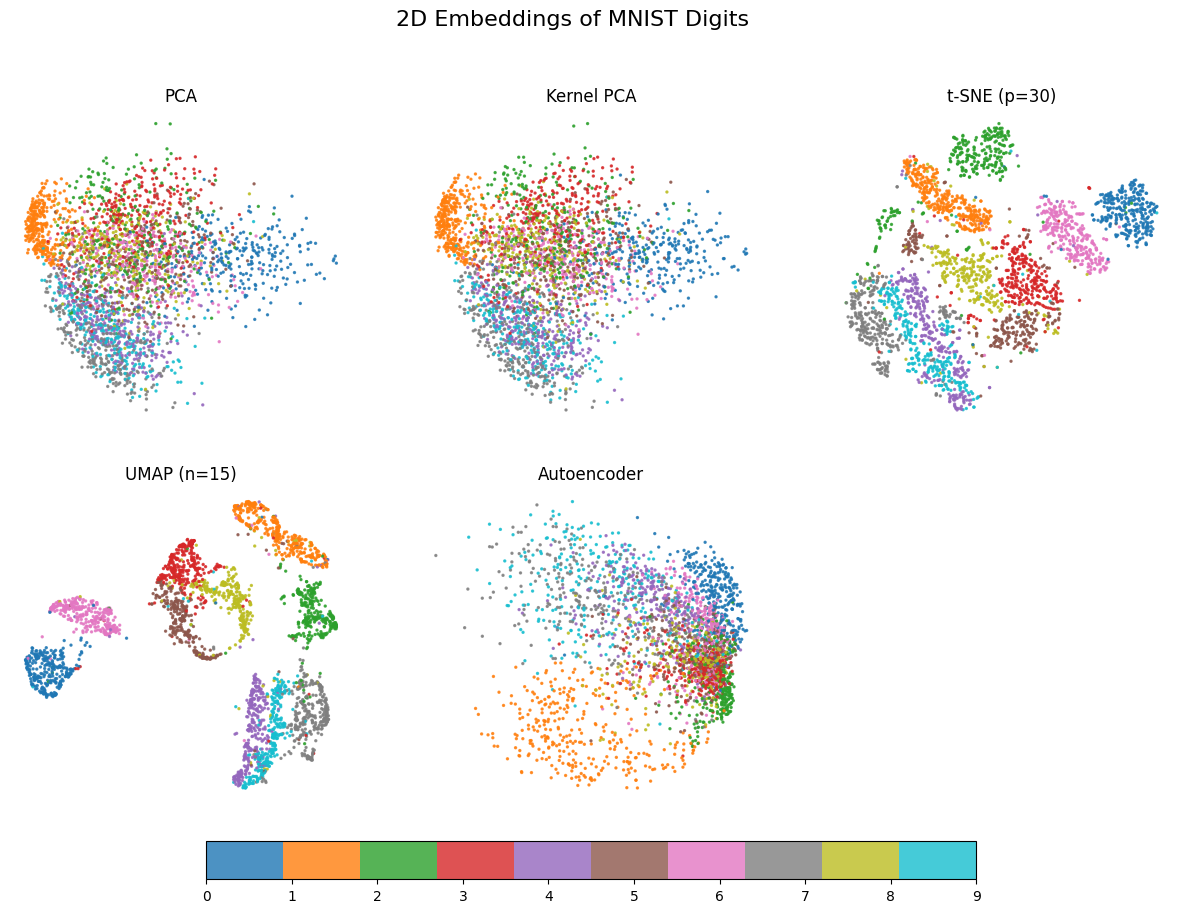

In [8]:
# Visualization: 2D Embeddings Comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Loop through all reductions
for i, (name, X_red) in enumerate(reduced.items()):
    scatter = axes[i].scatter(X_red[:, 0], X_red[:, 1], c=y_train, cmap='tab10', s=2, alpha=0.8)
    axes[i].set_title(name)
    axes[i].axis('off')

# Keep the remaining subplots clean
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Colorbar for the classes
# Add a colorbar legend
cbar = fig.colorbar(scatter, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05)
cbar.set_ticks(np.arange(10))

plt.suptitle('2D Embeddings of MNIST Digits', fontsize=16)
plt.show()

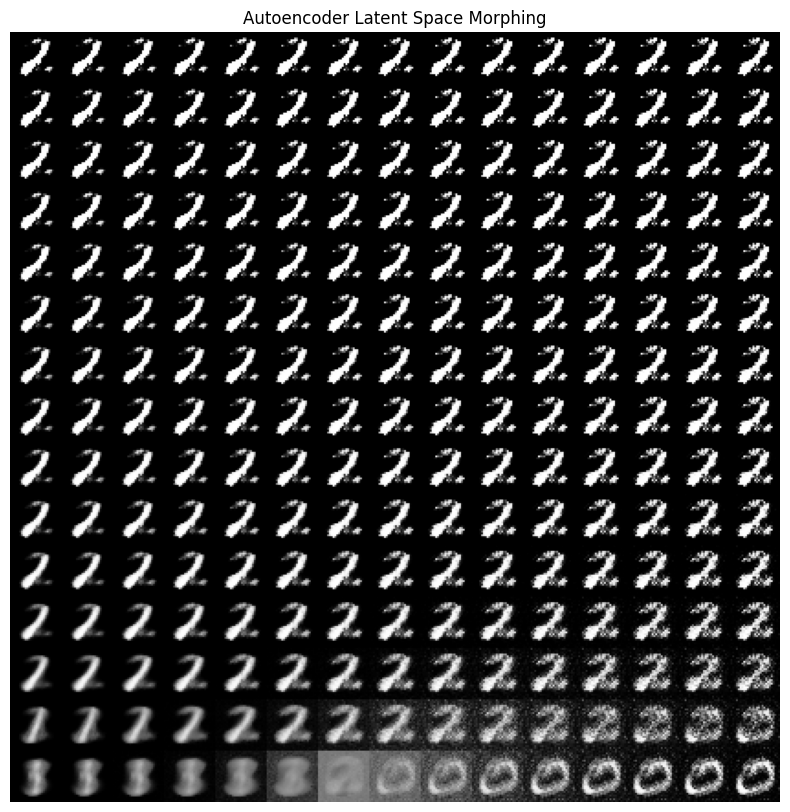

In [9]:
# Visualise Autoencoder Latent Space (Semantic Structure)
n_grid = 15 # Grid size
digit_size = 28 # MNIST images are 28x28
figure = np.zeros((digit_size * n_grid, digit_size * n_grid))

# Limit grid size to autoencoder latent limits
x_min, x_max = reduced['Autoencoder'][:, 0].min(), reduced['Autoencoder'][:, 0].max()
y_min, y_max = reduced['Autoencoder'][:, 1].min(), reduced['Autoencoder'][:, 1].max()

# Generate linearly spaced latent coordinates
grid_x = np.linspace(x_min, x_max, n_grid)
grid_y = np.linspace(y_min, y_max, n_grid)

# Decoder extraction: Input (2,) -> layers[-3](dense 64) -> layers[-2](dense 128) -> layers[-1](out 784)
decoder_input = layers.Input(shape=(encoding_dim,))
x = autoencoder.layers[-3](decoder_input)
x = autoencoder.layers[-2](x)
x_out = autoencoder.layers[-1](x)
decoder = models.Model(decoder_input, x_out)

# Decode latent space coordinates
for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size, j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.title('Autoencoder Latent Space Morphing')
plt.axis('off')
plt.show()

## Discussion
**Analysis of Latent Space:**
The autoencoder smoothly learns continuous features of MNIST digits. Scanning across axes, we can visually read digit thickness, rotation, and stylistic shifts interpolating out, representing captured real semantic structures unlike disjoint clusters.

**Computational Complexity Comparison:**
*   **PCA:** $\mathcal{O}(D^2N + D^3)$, fastest, extremely memory and computationally efficient.
*   **Kernel PCA:** $\mathcal{O}(N^3)$ training complexity for kernel matrix calculation, making it terribly slow for large datasets. High memory dependence.
*   **t-SNE:** $\mathcal{O}(N \log N)$ (with Barnes-Hut algorithm), moderate, mostly captures very localized neighborhoods optimally.
*   **UMAP:** $\mathcal{O}(N)$ empirically, much faster than t-SNE and scales significantly better, preserving relatively better global structure.
*   **Autoencoder:** $\mathcal{O}(W \cdot N \cdot E)$ (weights $\times$ samples $\times$ epochs), slower to train but scales perfectly via mini-batches. $\mathcal{O}(1)$ latency for out-of-sample forward pass projection.

**When Autoencoders Outperform PCA/t-SNE:**
Autoencoders surpass PCA by learning non-linear structures efficiently scaled across large data. They surpass manifold approaches (t-SNE/UMAP) in scenarios demanding **strictly reversible bidirectional transformations (encoding out-of-sample data exactly and decoding from novel latent zones)**, e.g., generative frameworks mapping continuous traits. They optimally handle distributed massive datasets that exceed memory limits of matrix-oriented $N \times N$ solutions via batch training.